In [1]:
from google.colab import files
uploaded = files.upload()

Saving agencia_dn_2500_registros.csv to agencia_dn_2500_registros.csv


In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('agencia_dn_2500_registros.csv')
df.head()

,Tipo_Servicio,Presupuesto_Cliente,Tiempo_Respuesta_Horas,Canal_Contacto,Numero_Consultas,Tipo_Cliente,Ubicacion_Cliente,Urgencia_Proyecto,Cantidad_Reuniones,Experiencia_Previa,Tiempo_Decision_Dias,Tamano_Proyecto,Contrata_Servicio
0,Página Web,14360,36,WhatsApp,4,Empresa,Trujillo,Media,5,Sí,29,Grande,Sí
1,Página Web,14349,36,TikTok,8,Empresa,Cusco,Media,0,No,21,Grande,No
2,Página Web,13913,49,WhatsApp,8,Empresa,Cusco,Media,4,Sí,7,Grande,Sí
3,Página Web,5627,40,Instagram,6,Empresa,Trujillo,Baja,1,No,24,Mediano,No
4,Tienda Virtual,12631,6,Web,2,Persona,Trujillo,Baja,5,No,29,Grande,Sí


In [4]:
df.tail(3)

,Tipo_Servicio,Presupuesto_Cliente,Tiempo_Respuesta_Horas,Canal_Contacto,Numero_Consultas,Tipo_Cliente,Ubicacion_Cliente,Urgencia_Proyecto,Cantidad_Reuniones,Experiencia_Previa,Tiempo_Decision_Dias,Tamano_Proyecto,Contrata_Servicio
2497,Sistema Web,12587,50,TikTok,4,Empresa,Piura,Alta,3,Sí,10,Grande,Sí
2498,Tienda Virtual,3187,16,Instagram,7,Empresa,Lima,Alta,4,Sí,11,Grande,Sí
2499,Página Web,11859,24,Instagram,4,Empresa,Lima,Media,1,Sí,14,Mediano,Sí


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Tipo_Servicio           2500 non-null   object
 1   Presupuesto_Cliente     2500 non-null   int64 
 2   Tiempo_Respuesta_Horas  2500 non-null   int64 
 3   Canal_Contacto          2500 non-null   object
 4   Numero_Consultas        2500 non-null   int64 
 5   Tipo_Cliente            2500 non-null   object
 6   Ubicacion_Cliente       2500 non-null   object
 7   Urgencia_Proyecto       2500 non-null   object
 8   Cantidad_Reuniones      2500 non-null   int64 
 9   Experiencia_Previa      2500 non-null   object
 10  Tiempo_Decision_Dias    2500 non-null   int64 
 11  Tamano_Proyecto         2500 non-null   object
 12  Contrata_Servicio       2500 non-null   object
dtypes: int64(5), object(8)
memory usage: 254.0+ KB


In [6]:
df.isnull().sum()

,0
Tipo_Servicio,0
Presupuesto_Cliente,0
Tiempo_Respuesta_Horas,0
Canal_Contacto,0
Numero_Consultas,0
Tipo_Cliente,0
Ubicacion_Cliente,0
Urgencia_Proyecto,0
Cantidad_Reuniones,0
Experiencia_Previa,0


In [7]:
print(df[df.duplicated()])

Empty DataFrame
Columns: [Tipo_Servicio, Presupuesto_Cliente, Tiempo_Respuesta_Horas, Canal_Contacto, Numero_Consultas, Tipo_Cliente, Ubicacion_Cliente, Urgencia_Proyecto, Cantidad_Reuniones, Experiencia_Previa, Tiempo_Decision_Dias, Tamano_Proyecto, Contrata_Servicio]
Index: []


In [8]:
from sklearn.preprocessing import LabelEncoder

In [9]:
df = df.drop_duplicates()

In [10]:
le = LabelEncoder()

In [34]:
encoders = {}

columnas = [
    'Tipo_Servicio',
    'Canal_Contacto',
    'Tipo_Cliente',
    'Ubicacion_Cliente',
    'Urgencia_Proyecto',
    'Experiencia_Previa',
    'Tamano_Proyecto',
    'Contrata_Servicio'
]

for col in columnas:
    encoder = LabelEncoder()
    df[col] = encoder.fit_transform(df[col])
    encoders[col] = encoder

In [35]:
df.head()

,Tipo_Servicio,Presupuesto_Cliente,Tiempo_Respuesta_Horas,Canal_Contacto,Numero_Consultas,Tipo_Cliente,Ubicacion_Cliente,Urgencia_Proyecto,Cantidad_Reuniones,Experiencia_Previa,Tiempo_Decision_Dias,Tamano_Proyecto,Contrata_Servicio
0,0,14360,36,4,4,0,4,2,5,1,29,0,1
1,0,14349,36,2,8,0,1,2,0,0,21,0,0
2,0,13913,49,4,8,0,1,2,4,1,7,0,1
3,0,5627,40,1,6,0,4,1,1,0,24,1,0
4,2,12631,6,3,2,1,4,1,5,0,29,0,1


In [36]:
X = df.drop('Contrata_Servicio', axis=1)

In [37]:
y = df['Contrata_Servicio']

In [38]:
from sklearn.model_selection import train_test_split

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [40]:
from sklearn.linear_model import LogisticRegression



In [41]:
modelo = LogisticRegression()

In [42]:
modelo = LogisticRegression(max_iter=5000)

In [43]:
modelo.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

In [44]:
predicciones = modelo.predict(X_test)

In [45]:
from sklearn.metrics import accuracy_score

In [46]:
accuracy = accuracy_score(y_test, predicciones)
print('Accuracy:', accuracy)

Accuracy: 0.85


In [47]:
from sklearn.metrics import confusion_matrix

In [48]:
matriz = confusion_matrix(y_test, predicciones)

In [49]:
print(matriz)

[[141  38]
 [ 37 284]]


In [50]:
from sklearn.metrics import classification_report

In [51]:
print(classification_report(y_test, predicciones))

              precision    recall  f1-score   support

           0       0.79      0.79      0.79       179
           1       0.88      0.88      0.88       321

    accuracy                           0.85       500
   macro avg       0.84      0.84      0.84       500
weighted avg       0.85      0.85      0.85       500



In [55]:
import joblib

joblib.dump(encoders, 'encoders.pkl')
joblib.dump(modelo, 'modelo_agencia_dn.pkl')

['modelo_agencia_dn.pkl']

In [56]:
from google.colab import files

files.download('encoders.pkl')
files.download('modelo_agencia_dn.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

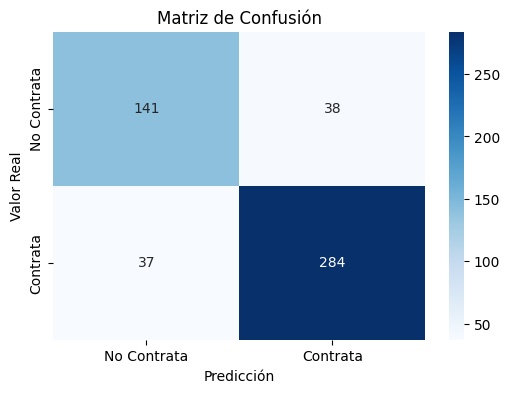

In [29]:
#Matriz de confusion
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

matriz = confusion_matrix(y_test, predicciones)

plt.figure(figsize=(6,4))
sns.heatmap(matriz,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['No Contrata', 'Contrata'],
            yticklabels=['No Contrata', 'Contrata'])

plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión')
plt.show()

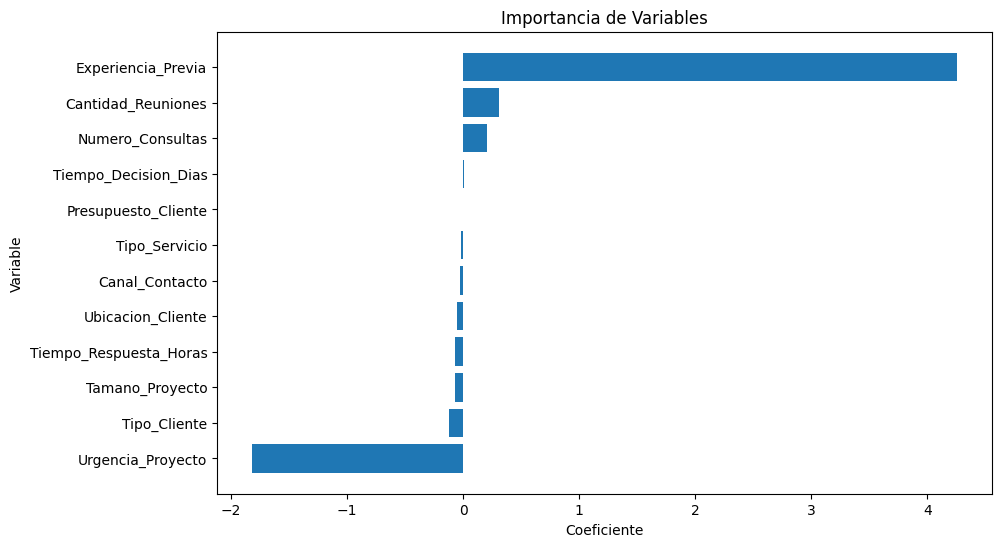

In [30]:
#importancia de valores
import pandas as pd
import matplotlib.pyplot as plt

coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': modelo.coef_[0]
})

coeficientes = coeficientes.sort_values(by='Coeficiente')

plt.figure(figsize=(10,6))
plt.barh(coeficientes['Variable'], coeficientes['Coeficiente'])
plt.title('Importancia de Variables')
plt.xlabel('Coeficiente')
plt.ylabel('Variable')
plt.show()

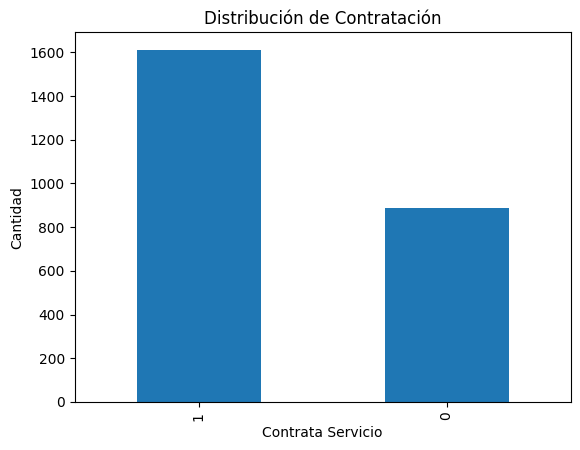

In [31]:
#dsitribucion de clientes que contrataron

import matplotlib.pyplot as plt

df['Contrata_Servicio'].value_counts().plot(
    kind='bar'
)

plt.title('Distribución de Contratación')
plt.xlabel('Contrata Servicio')
plt.ylabel('Cantidad')
plt.show()
